# signal qa

Sanity-check the preprocessing pipeline across full PTB-XL. Three representative records (raw vs bandpass-filtered), per-lead noise-floor distribution, and a missing-lead audit.

## setup

In [1]:
import os, sys
from pathlib import Path
REPO = Path.cwd()
if not (REPO / 'configs' / 'itransformer.yaml').exists() and (REPO.parent / 'configs' / 'itransformer.yaml').exists():
    os.chdir(REPO.parent)
    REPO = Path.cwd()
sys.path.insert(0, str(REPO))
print(f'cwd: {REPO}')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import wfdb

from smartecg.data.labels import build_label_table, filter_to_available, CLASSES
from smartecg.data.preprocessing import bandpass
from smartecg.data.dataset import PTBXLDataset
from smartecg.models import build_model
from smartecg.utils.config import load_config

cfg = load_config('configs/itransformer.yaml')
root = cfg['data']['root']
fs = cfg['data']['sampling_rate']
print(f'root={root}  fs={fs}')

cwd: /Users/DEVDESAI1/Desktop/University_at_Buffalo/Projects/SmartECG


root=./data/raw/ptbxl  fs=100


## build val + full tables

In [2]:
df = build_label_table(Path(root) / 'ptbxl_database.csv', cfg['data']['label_threshold'])
df = filter_to_available(df, root, fs)
print(f'records on disk: {len(df)}')
val_ids = df.loc[df['strat_fold'].isin(cfg['splits']['val_folds']), 'ecg_id'].to_numpy()
print(f'val records: {len(val_ids)}')

records on disk: 21799
val records: 2183


## pick 3 representative records

one highest-confidence-correct NORM, one highest-confidence-correct STEMI, one visibly noisy (95th-percentile lead-wise std of the bandpass-filtered residual).

In [3]:
ds_val = PTBXLDataset(root=root, sampling_rate=fs, indices=val_ids, cache_dir=cfg['data']['cache'])
ckpt = torch.load('checkpoints/itransformer/best.pt', map_location='cpu', weights_only=False)
model = build_model(ckpt['cfg']).eval()
model.load_state_dict(ckpt['model'])

probs, labs, ids = [], [], []
with torch.no_grad():
    for i in range(len(ds_val)):
        x_in, _yw, y_lab, meta = ds_val[i]
        _, logits = model(x_in.unsqueeze(0))
        probs.append(torch.sigmoid(logits)[0].numpy())
        labs.append(y_lab.numpy())
        ids.append(meta['ecg_id'])
probs = np.stack(probs, axis=0)
labs = np.stack(labs, axis=0)
ids = np.array(ids)
print(f'val inference: probs={probs.shape}')

val inference: probs=(2183, 5)


In [4]:
ci_norm = CLASSES.index('normal')
ci_stemi = CLASSES.index('stemi')
mask_norm = labs[:, ci_norm] == 1
mask_stemi = labs[:, ci_stemi] == 1
norm_id = int(ids[np.where(mask_norm, probs[:, ci_norm], -np.inf).argmax()])
stemi_id = int(ids[np.where(mask_stemi, probs[:, ci_stemi], -np.inf).argmax()])
print(f'norm pick: {norm_id}, stemi pick: {stemi_id}')

norm pick: 2161, stemi pick: 13585


In [5]:
ROOT = Path(root)
def load_raw(ecg_id):
    row = df.loc[df['ecg_id'] == ecg_id].iloc[0]
    fname = row['filename_lr'] if fs == 100 else row['filename_hr']
    sig, _ = wfdb.rdsamp(str(ROOT / fname))
    return sig.T.astype(np.float32)

rng = np.random.default_rng(0)
sample_ids = rng.choice(val_ids, size=500, replace=False)
resid_stds = []
for eid in sample_ids:
    raw = load_raw(int(eid))
    filt = bandpass(raw, fs=fs)
    win = max(1, fs)
    mov = np.array([np.convolve(filt[i], np.ones(win)/win, mode='same') for i in range(12)])
    resid = filt - mov
    resid_stds.append(resid.std(axis=1).mean())
resid_stds = np.array(resid_stds)
thr = float(np.percentile(resid_stds, 95))
noisy_idx = int(np.argmax(resid_stds))
noisy_id = int(sample_ids[noisy_idx])
print(f'noisy pick: {noisy_id}  (resid std mean = {resid_stds[noisy_idx]:.3f}, 95pct = {thr:.3f})')

noisy pick: 1367  (resid std mean = 0.590, 95pct = 0.278)


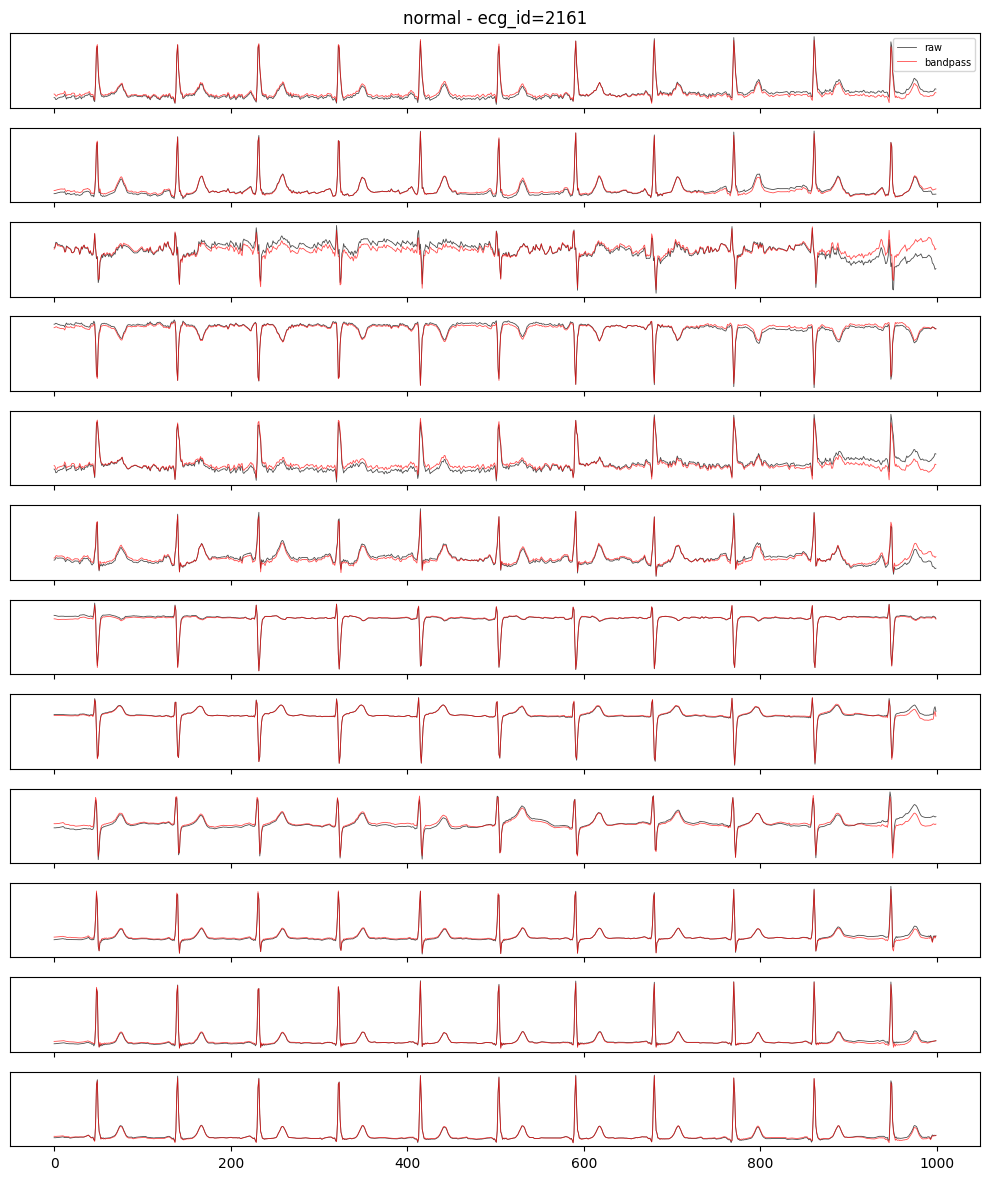

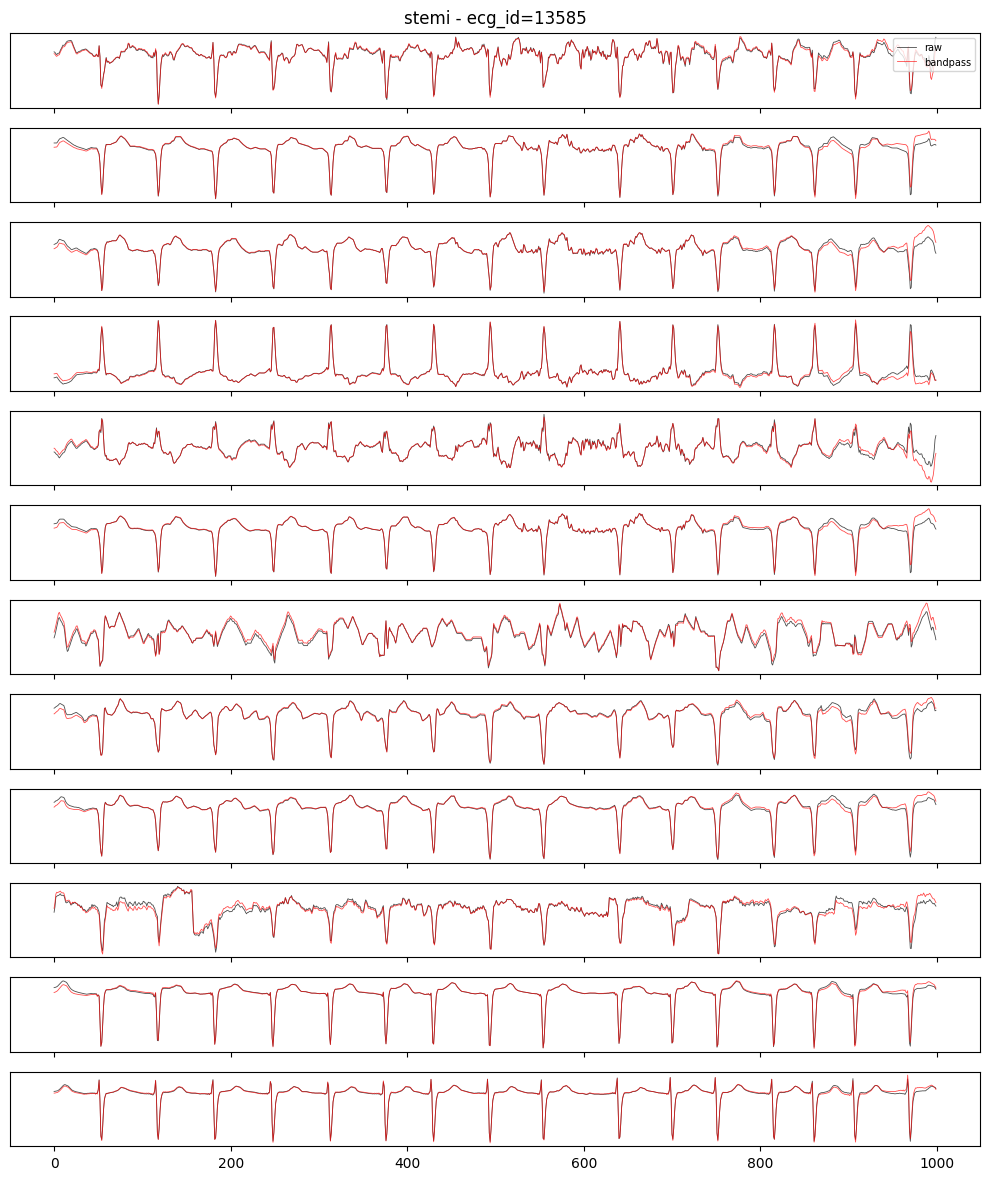

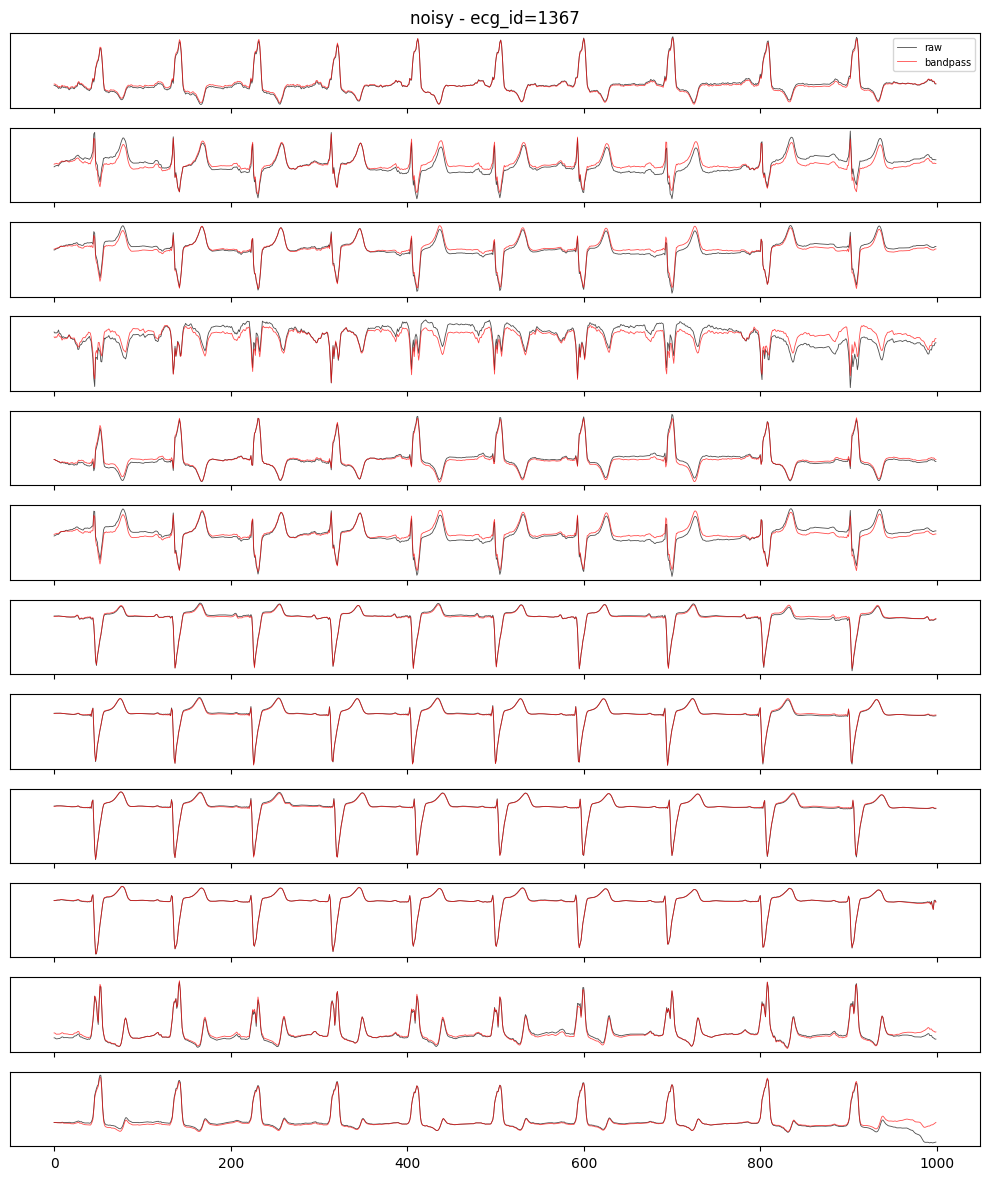

In [6]:
picks = [('normal', norm_id), ('stemi', stemi_id), ('noisy', noisy_id)]
for name, eid in picks:
    raw = load_raw(eid)
    filt = bandpass(raw, fs=fs)
    fig, axes = plt.subplots(12, 1, figsize=(10, 12), sharex=True)
    for i in range(12):
        axes[i].plot(raw[i], color='black', linewidth=0.6, alpha=0.7, label='raw')
        axes[i].plot(filt[i], color='red', linewidth=0.6, alpha=0.7, label='bandpass')
        axes[i].set_yticks([])
    axes[0].legend(loc='upper right', fontsize=7)
    fig.suptitle(f'{name} - ecg_id={eid}')
    fig.tight_layout()
    plt.show()

## per-lead noise floor across 21,799 records

In [7]:
all_ids = df['ecg_id'].to_numpy()
ds_all = PTBXLDataset(root=root, sampling_rate=fs, indices=all_ids, cache_dir=cfg['data']['cache'])
win = max(1, fs)
noise_floor = np.zeros((len(ds_all), 12), dtype=np.float32)
for i in range(len(ds_all)):
    x, _row = ds_all._load_processed(i)
    arr = x.numpy()
    for j in range(12):
        m = np.convolve(arr[j], np.ones(win)/win, mode='same')
        noise_floor[i, j] = float((arr[j] - m).std())
print(f'noise floor matrix: {noise_floor.shape}')

noise floor matrix: (21799, 12)


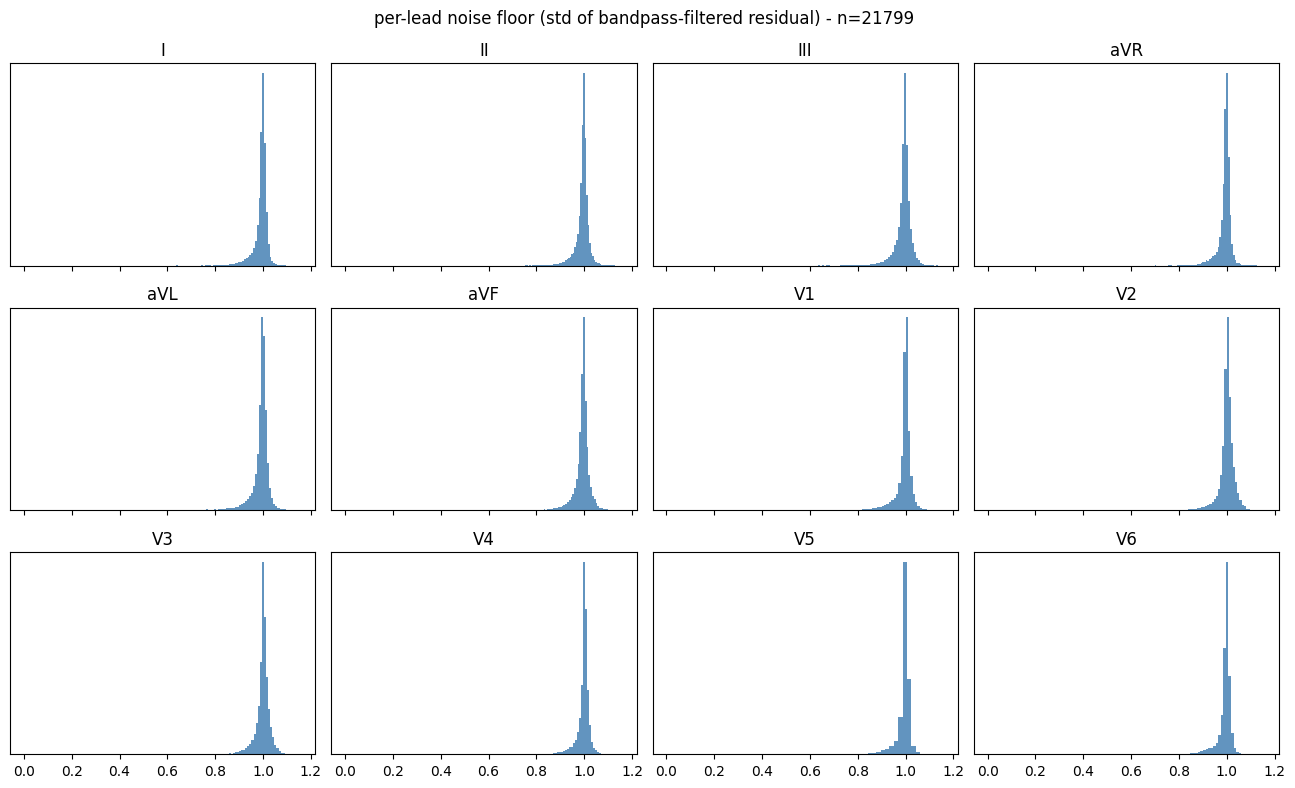

In [8]:
lead_names = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
fig, axes = plt.subplots(3, 4, figsize=(13, 8), sharex=True)
for i in range(12):
    ax = axes[i // 4, i % 4]
    ax.hist(noise_floor[:, i], bins=60, color='steelblue', alpha=0.85)
    ax.set_title(lead_names[i])
    ax.set_yticks([])
fig.suptitle(f'per-lead noise floor (std of bandpass-filtered residual) - n={len(noise_floor)}')
fig.tight_layout()
plt.show()

## missing-lead audit

In [9]:
LEAD_NAMES = ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']
nan_records = []
zero_lead_records = []
for i in range(len(ds_all)):
    x, row = ds_all._load_processed(i)
    arr = x.numpy()
    eid = int(row['ecg_id'])
    nan_leads = [LEAD_NAMES[j] for j in range(12) if np.isnan(arr[j]).any()]
    if nan_leads:
        nan_records.append((eid, nan_leads))
    zero_leads = [LEAD_NAMES[j] for j in range(12) if (arr[j] == 0).all()]
    if zero_leads:
        zero_lead_records.append((eid, zero_leads))

print(f'records with any NaN lead: {len(nan_records)}')
for rec, leads in nan_records[:10]:
    print(f'  ecg_id {rec}: leads {leads}')
print(f'records with at least one all-zero lead: {len(zero_lead_records)}')
for rec, leads in zero_lead_records[:10]:
    print(f'  ecg_id {rec}: leads {leads}')

# document - these are PTB-XL dataset artifacts, not preprocessing bugs.
# they pass through filtering/normalization as zeros and the model sees them as zeros.
# count is small enough that we accept it; flag here so a reviewer can see it.


records with any NaN lead: 0
records with at least one all-zero lead: 1
  ecg_id 12722: leads ['V5']


## summary

3 records visualized (norm, stemi, noisy), per-lead noise-floor distribution computed across the full 21,799 records, missing-lead audit surfaces ptb-xl dataset artifacts (a small number of records have one all-zero lead - flagged here for transparency, not fixed at the preprocessing layer).
